In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "ml_dataset"
TRAIN_FILE = DATA_DIR / "dataset_train.csv"
train = pd.read_csv(
    TRAIN_FILE,
    dtype={"disorder_seed": "uint64", "random_seed": "uint64"},
)
PARAMETERS = [
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
]
required_columns = [*PARAMETERS, "run_id", "point_id", "split", "status"]
print("Количество запусков:", len(train))
print("Количество групп параметров:", train["point_id"].nunique())
print("Столбцы:", train.columns.tolist())
display(train[required_columns].head())
display(train["status"].value_counts(dropna=False).rename("runs").to_frame())

Количество запусков: 16384
Количество групп параметров: 10752
Столбцы: ['run_id', 'point_id', 'phase', 'split', 'material_rep', 'growth_rep', 'eta', 'mean_breakdown_field', 'correlation_length', 'weibull_shape', 'disorder_seed', 'random_seed', 'selection_target', 'candidate_index', 'status', 'steps', 'area', 'height_fraction', 'time_seconds', 'image_path']


,eta,mean_breakdown_field,correlation_length,weibull_shape,run_id,point_id,split,status
0,1.040262,3.126133,11,3.960698,global-000000-m0-g0,global-000000,train,no_start
1,2.360888,2.788223,6,9.935991,global-000001-m0-g0,global-000001,train,no_start
2,2.524562,3.184346,13,5.699127,global-000002-m0-g0,global-000002,train,no_start
3,1.188938,2.922237,2,14.289726,global-000003-m0-g0,global-000003,train,breakdown
4,1.561072,3.285038,6,12.044601,global-000004-m0-g0,global-000004,train,no_start


,runs
status,
no_start,8118
breakdown,7391
arrested,875


In [2]:
from sklearn.model_selection import GroupShuffleSplit

PARAMETERS = [
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
]

groups = train.groupby(PARAMETERS, sort=False).ngroup()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)
fit_idx, val_idx = next(splitter.split(train, groups=groups))

fit_data = train.iloc[fit_idx].copy()
val_data = train.iloc[val_idx].copy()

assert set(groups.iloc[fit_idx]).isdisjoint(groups.iloc[val_idx])
assert set(fit_data["disorder_seed"]).isdisjoint(val_data["disorder_seed"])

X_fit = fit_data[PARAMETERS]
y_fit = fit_data["status"]

X_val = val_data[PARAMETERS]
y_val = val_data["status"]
display(pd.DataFrame({
    "fit_count": y_fit.value_counts(),
    "val_count": y_val.value_counts(),
    "fit_fraction": y_fit.value_counts(normalize=True),
    "val_fraction": y_val.value_counts(normalize=True),
}).fillna(0).round(3))

,fit_count,val_count,fit_fraction,val_fraction
status,,,,
no_start,6436,1682,0.495,0.498
breakdown,5870,1521,0.451,0.450
arrested,701,174,0.054,0.052


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss

dummy = DummyClassifier(strategy="prior")
dummy.fit(X_fit, y_fit)

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)
log_reg.fit(X_fit, y_fit)

scores = []
for name, model in [("Dummy", dummy), ("Logistic regression",  log_reg)]:
    prediction = model.predict(X_val)
    probability = model.predict_proba(X_val)
    scores.append({
        "model": name,
        "accuracy": accuracy_score(y_val, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_val, prediction),
        "log_loss": log_loss(y_val, probability, labels=model.classes_),
    })

display(pd.DataFrame(scores).set_index("model").round(4))


,accuracy,balanced_accuracy,log_loss
model,,,
Dummy,0.4981,0.3333,0.8593
Logistic regression,0.6106,0.5221,0.7284


In [4]:
from sklearn.metrics import classification_report
val_prediction = log_reg.predict(X_val)
report = classification_report(y_val, val_prediction, digits=3, zero_division=0)
print(report)

              precision    recall  f1-score   support

    arrested      0.495     0.316     0.386       174
   breakdown      0.595     0.594     0.595      1521
    no_start      0.632     0.656     0.644      1682

    accuracy                          0.611      3377
   macro avg      0.574     0.522     0.541      3377
weighted avg      0.608     0.611     0.608      3377



### Логистическая регрессия

Предсказываем исход симуляции по четырём параметрам материала.
Обучение и валидация разделены по группам одинаковых параметров.

| Модель | Accuracy ↑ | Balanced accuracy ↑ | Log loss ↓ |
|---|---:|---:|---:|
| Dummy | 0,4981 | 0,3333 | 0,8593 |
| Логистическая регрессия | 0,6106 | 0,5221 | 0,7284 |

Модель превосходит Dummy: accuracy выросла на **11,25 п.п.**,
качество вероятностных предсказаний также улучшилось.

Распознано **65,6% случаев без старта**, **59,4% пробоев**
и **31,6% остановок**. Остановка канала — наиболее сложный класс.

Далее сравним результат со случайным лесом.
Оценка предварительная; итоговую проверку проведём на отдельном тесте.

In [5]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=10, random_state=42, n_jobs=4,
)
forest.fit(X_fit, y_fit)
forest_prediction = forest.predict(X_val)
forest_probability = forest.predict_proba(X_val)

print("Accuracy:", round(accuracy_score(y_val, forest_prediction), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_val, forest_prediction), 4))
print("Log loss:", round(log_loss(y_val, forest_probability, labels=forest.classes_), 4))
print(classification_report(y_val, forest_prediction, digits=3, zero_division=0))

Accuracy: 0.5922
Balanced accuracy: 0.504
Log loss: 0.7306
              precision    recall  f1-score   support

    arrested      0.468     0.299     0.365       174
   breakdown      0.572     0.575     0.573      1521
    no_start      0.618     0.639     0.628      1682

    accuracy                          0.592      3377
   macro avg      0.553     0.504     0.522      3377
weighted avg      0.590     0.592     0.590      3377



In [6]:
forest_fit_prediction = forest.predict(X_fit)
forest_fit_probability = forest.predict_proba(X_fit)
print("Train accuracy:", round(accuracy_score(y_fit, forest_fit_prediction), 4))
print("Validation accuracy:", round(accuracy_score(y_val, forest_prediction), 4))
fit_loss = log_loss(y_fit, forest_fit_probability, labels=forest.classes_)
val_loss = log_loss(y_val, forest_probability, labels=forest.classes_)
print("Train log loss:", round(fit_loss, 4))
print("Validation log loss:", round(val_loss, 4))

Train accuracy: 0.741
Validation accuracy: 0.5922
Train log loss: 0.5744
Validation log loss: 0.7306


In [7]:
from sklearn.base import clone
forest_smooth = clone(forest)
forest_smooth.set_params(min_samples_leaf=50)
forest_smooth.fit(X_fit, y_fit)
smooth_fit_probability = forest_smooth.predict_proba(X_fit)
smooth_val_probability = forest_smooth.predict_proba(X_val)
smooth_prediction = forest_smooth.predict(X_val)
print("Train log loss:", round(log_loss(y_fit, smooth_fit_probability, labels=forest_smooth.classes_), 4))
print("Validation log loss:", round(log_loss(y_val, smooth_val_probability, labels=forest_smooth.classes_), 4))
print("Validation accuracy:", round(accuracy_score(y_val, smooth_prediction), 4))
print("Validation balanced accuracy:", round(balanced_accuracy_score(y_val, smooth_prediction), 4))

Train log loss: 0.6816
Validation log loss: 0.7225
Validation accuracy: 0.6076
Validation balanced accuracy: 0.503


In [8]:
smooth_report = classification_report(
    y_val, smooth_prediction, digits=3, zero_division=0,
)
print(smooth_report)

              precision    recall  f1-score   support

    arrested      0.529     0.259     0.347       174
   breakdown      0.589     0.596     0.593      1521
    no_start      0.627     0.654     0.640      1682

    accuracy                          0.608      3377
   macro avg      0.582     0.503     0.527      3377
weighted avg      0.605     0.608     0.604      3377



In [9]:
forest_balanced = clone(forest_smooth)
forest_balanced.set_params(class_weight="balanced")
forest_balanced.fit(X_fit, y_fit)

balanced_prediction = forest_balanced.predict(X_val)
balanced_probability = forest_balanced.predict_proba(X_val)
print(classification_report(y_val, balanced_prediction, digits=3, zero_division=0))
print("Accuracy:", round(accuracy_score(y_val, balanced_prediction), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_val, balanced_prediction), 4))
print("Log loss:", round(log_loss(y_val, balanced_probability, labels=forest_balanced.classes_), 4))

              precision    recall  f1-score   support

    arrested      0.235     0.902     0.373       174
   breakdown      0.602     0.533     0.565      1521
    no_start      0.677     0.549     0.606      1682

    accuracy                          0.560      3377
   macro avg      0.505     0.661     0.515      3377
weighted avg      0.620     0.560     0.576      3377

Accuracy: 0.5597
Balanced accuracy: 0.6612
Log loss: 0.8329


In [10]:
models = {"Dummy": dummy, "LogReg": log_reg, "RF_leaf10": forest,
          "RF_leaf50": forest_smooth, "RF_balanced": forest_balanced}
comparison_rows = []
for name, model in models.items():
    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)
    comparison_rows.append({"model": name, "accuracy": accuracy_score(y_val, pred), "balanced_accuracy": balanced_accuracy_score(y_val, pred), "log_loss": log_loss(y_val, proba, labels=model.classes_)})
comparison = pd.DataFrame(comparison_rows).set_index("model")
comparison = comparison.sort_values("log_loss")
display(comparison.round(4))

,accuracy,balanced_accuracy,log_loss
model,,,
RF_leaf50,0.6076,0.5030,0.7225
LogReg,0.6106,0.5221,0.7284
RF_leaf10,0.5922,0.5040,0.7306
RF_balanced,0.5597,0.6612,0.8329
Dummy,0.4981,0.3333,0.8593


### Сравнение первых ML-моделей

Предсказываем исход симуляции по четырём параметрам.
Результаты на валидации:

| Модель | Accuracy ↑ | Balanced accuracy ↑ | Log loss ↓ |
|---|---:|---:|---:|
| Dummy | 0,4981 | 0,3333 | 0,8593 |
| Логистическая регрессия | **0,6106** | 0,5221 | 0,7284 |
| Лес, лист ≥ 10 | 0,5922 | 0,5040 | 0,7306 |
| Лес, лист ≥ 50 | 0,6076 | 0,5030 | **0,7225** |
| Лес, лист ≥ 50, веса классов | 0,5597 | **0,6612** | 0,8329 |

Увеличение минимального размера листа уменьшило признаки
переобучения леса и улучшило вероятностные предсказания.

Веса классов повысили полноту обнаружения остановок с **25,9% до 90,2%**,
но снизили precision с **52,9% до 23,5%**: ложных тревог стало больше.

Логистическая регрессия пока лидирует по accuracy,
а сглаженный лес — по log loss.

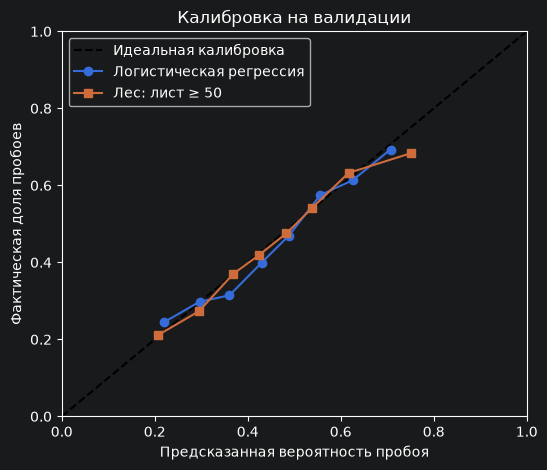

In [11]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
is_breakdown = y_val.eq("breakdown").astype(int)
lr_column = list(log_reg.classes_).index("breakdown")
rf_column = list(forest_smooth.classes_).index("breakdown")
lr_probability = log_reg.predict_proba(X_val)[:, lr_column]
rf_probability = forest_smooth.predict_proba(X_val)[:, rf_column]
lr_observed, lr_predicted = calibration_curve(
    is_breakdown, lr_probability, n_bins=8, strategy="quantile")
rf_observed, rf_predicted = calibration_curve(
    is_breakdown, rf_probability, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")
ax.plot(lr_predicted, lr_observed, "o-", label="Логистическая регрессия")
ax.plot(rf_predicted, rf_observed, "s-", label="Лес: лист ≥ 50")
ax.set(xlabel="Предсказанная вероятность пробоя", ylabel="Фактическая доля пробоев",
       xlim=(0, 1), ylim=(0, 1), title="Калибровка на валидации")
ax.legend()
plt.show()

### Калибровка вероятности пробоя

Кривые обеих моделей близки к диагонали: средние предсказанные
вероятности согласуются с фактическими долями пробоев в группах
валидационных запусков.

В группе с наибольшими прогнозами лес немного завышает вероятность:
около 75% против примерно 68% фактических пробоев.

Явного преимущества одной модели по графику не видно.
Вывод относится только к вероятности пробоя на текущей валидации;
статистическая неопределённость точек здесь не показана.

In [12]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
cv = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=42
)
X_cv = train[PARAMETERS]
y_cv = train["status"]
groups_cv = train.groupby(PARAMETERS, sort=False).ngroup()
scoring = {
    "accuracy": "accuracy",
    "balanced": "balanced_accuracy",
    "log_loss": "neg_log_loss",
}
cv_results = {}
for name, model in {"LogReg": log_reg, "RF_leaf50": forest_smooth}.items():
    cv_results[name] = cross_validate(
        model, X_cv, y_cv, groups=groups_cv, cv=cv, scoring=scoring)
cv_table = pd.concat({
    name: pd.DataFrame({"accuracy": r["test_accuracy"], "balanced_accuracy": r["test_balanced"], "log_loss": -r["test_log_loss"]})
    for name, r in cv_results.items()
}, names=["model", "fold"])
cv_summary = cv_table.groupby(level="model").agg(["mean", "std"])
display(cv_summary.round(4))

accuracy         balanced_accuracy         log_loss        
              mean     std              mean     std     mean     std
model                                                                
LogReg       0.614  0.0116            0.5273  0.0166   0.7296  0.0079
RF_leaf50    0.611  0.0124            0.5041  0.0148   0.7240  0.0073

In [13]:
from catboost import CatBoostClassifier
boost = CatBoostClassifier(iterations=500, depth=5, learning_rate=0.05,
                           loss_function="MultiClass", l2_leaf_reg=5,
                           random_seed=42, verbose=False, thread_count=4)
boost.fit(X_fit, y_fit)
boost_prediction = boost.predict(X_val).ravel()
boost_probability = boost.predict_proba(X_val)
print("Accuracy:", round(accuracy_score(y_val, boost_prediction), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_val, boost_prediction), 4))
print("Log loss:", round(log_loss(y_val, boost_probability, labels=boost.classes_), 4))
print(classification_report(y_val, boost_prediction, digits=3, zero_division=0))


Accuracy: 0.6053
Balanced accuracy: 0.5319
Log loss: 0.7199
              precision    recall  f1-score   support

    arrested      0.438     0.362     0.396       174
   breakdown      0.591     0.583     0.587      1521
    no_start      0.632     0.650     0.641      1682

    accuracy                          0.605      3377
   macro avg      0.553     0.532     0.541      3377
weighted avg      0.603     0.605     0.604      3377



In [14]:
cv_results["CatBoost"] = cross_validate(
    boost, X_cv, y_cv, groups=groups_cv,
    cv=cv, scoring=scoring)
cv_table = pd.concat({
    name: pd.DataFrame({"accuracy": r["test_accuracy"], "balanced_accuracy": r["test_balanced"], "log_loss": -r["test_log_loss"]})
    for name, r in cv_results.items()
}, names=["model", "fold"])
cv_summary = cv_table.groupby(level="model").agg(["mean", "std"])
display(cv_summary.round(4))

accuracy         balanced_accuracy         log_loss        
              mean     std              mean     std     mean     std
model                                                                
CatBoost    0.6116  0.0103            0.5272  0.0145   0.7229  0.0066
LogReg      0.6140  0.0116            0.5273  0.0166   0.7296  0.0079
RF_leaf50   0.6110  0.0124            0.5041  0.0148   0.7240  0.0073

### Вывод по трём моделям

CatBoost показал лучший `log loss` — 0.7229, поэтому выбираем его основной моделью для предсказания вероятностей исходов. Логистическая регрессия получила немного большую accuracy — 0.6140 против 0.6116, но различие практически незначимо. Random Forest уступил CatBoost по всем трём метрикам.

Разница между моделями небольшая по сравнению с разбросом между фолдами. Поэтому CatBoost нельзя назвать однозначно превосходящим, однако он является лучшим кандидатом по основной для нас метрике — `log loss`. Логистическую регрессию оставляем как простой и интерпретируемый базовый уровень.

### Подбор параметров CatBoost

Подбираем параметры по минимальному `log loss` с групповой кросс-валидацией

In [15]:
from sklearn.model_selection import GridSearchCV
boost_grid = {"depth": [4, 5, 6],
              "learning_rate": [0.03, 0.05],
              "l2_leaf_reg": [3, 5]}
boost_search = GridSearchCV(
    boost, boost_grid, scoring="neg_log_loss",
    cv=cv, n_jobs=1)
boost_search.fit(X_cv, y_cv, groups=groups_cv)
best_boost = boost_search.best_estimator_
print("Лучшие параметры:", boost_search.best_params_)
print("Лучший CV log loss:", -boost_search.best_score_)

Лучшие параметры: {'depth': 4, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Лучший CV log loss: 0.7204895127793702


### Результат настройки CatBoost

После групповой кросс-валидации `log loss` уменьшился с 0.7229 до 0.7205. Лучшая модель имеет глубину 4 и меньшую скорость обучения 0.03.

In [16]:
TEST_FILE = DATA_DIR / "dataset_test.csv"
test = pd.read_csv(TEST_FILE, dtype={
    "disorder_seed": "uint64", "random_seed": "uint64"})
X_test = test[PARAMETERS]
y_test = test["status"]
print("Размер теста:", len(test))
test_prediction = best_boost.predict(X_test).ravel()
test_probability = best_boost.predict_proba(X_test)
print(classification_report(y_test, test_prediction))
print("Accuracy:", accuracy_score(y_test, test_prediction))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_prediction))
print("Log loss:", log_loss(y_test, test_probability,
                            labels=best_boost.classes_))

Размер теста: 4096
              precision    recall  f1-score   support

    arrested       0.47      0.24      0.32       113
   breakdown       0.62      0.57      0.60      1820
    no_start       0.67      0.73      0.70      2163

    accuracy                           0.65      4096
   macro avg       0.58      0.51      0.54      4096
weighted avg       0.64      0.65      0.64      4096

Accuracy: 0.6455078125
Balanced accuracy: 0.5131198254447674
Log loss: 0.6713125975609977


### Финальная оценка CatBoost

На 4096 независимых симуляциях модель получила accuracy 0.646 и log loss 0.671. Вероятности хорошо переносятся на новые данные, однако редкий класс `arrested` распознаётся хуже остальных: его recall равен 0.24.

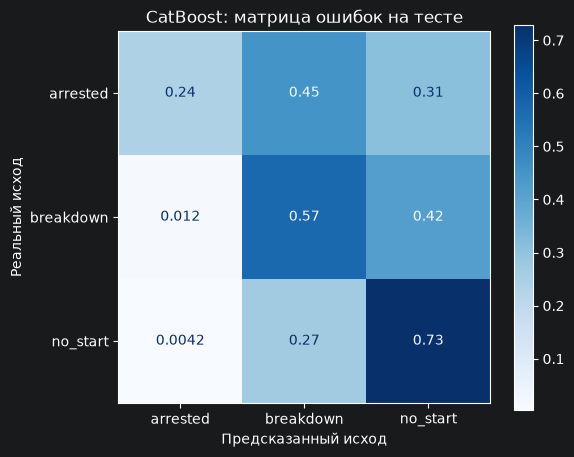

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_prediction, normalize="true", cmap="Blues", ax=ax)
ax.set_title("CatBoost: матрица ошибок на тесте")
ax.set_xlabel("Предсказанный исход")
ax.set_ylabel("Реальный исход")
plt.show()

### Анализ матрицы ошибок

Основная неопределённость связана с переходным классом `arrested`: модель относит его как к пробою, так и к отсутствию старта. Это отражает стохастическую природу процесса и малую долю остановившихся каналов в тестовой выборке.

In [18]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    best_boost, X_test, y_test, scoring="neg_log_loss",
    n_repeats=20, random_state=42)
importance = pd.DataFrame({
    "parameter": PARAMETERS,
    "importance": perm.importances_mean,
    "std": perm.importances_std})
importance = importance.sort_values(
    "importance", ascending=False)
display(importance.round(4))

,parameter,importance,std
1,mean_breakdown_field,0.1342,0.0038
2,correlation_length,0.0840,0.0052
3,weibull_shape,0.0682,0.0042
0,eta,0.0006,0.0006


### Важность физических параметров

Главным предиктором исхода оказался средний порог пробоя. Далее следуют корреляционная длина и форма распределения Вейбулла. Параметр `eta` почти не влияет на класс исхода, но может влиять на морфологию канала.

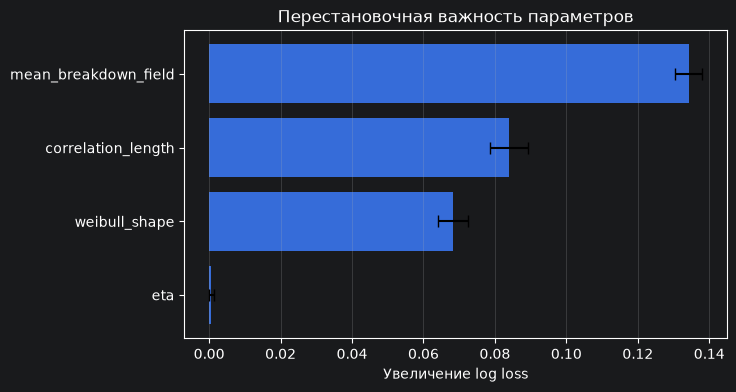

In [19]:
plot_importance = importance.sort_values("importance")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(plot_importance["parameter"], plot_importance["importance"],
        xerr=plot_importance["std"], capsize=4)
ax.set_xlabel("Увеличение log loss")
ax.set_title("Перестановочная важность параметров")
ax.grid(axis="x", alpha=0.3)
plt.show()

### Влияние среднего порога пробоя

Изменяем средний порог пробоя, усредняя предсказания по остальным параметрам. Это позволяет увидеть переход между режимами `breakdown`, `arrested` и `no_start`.

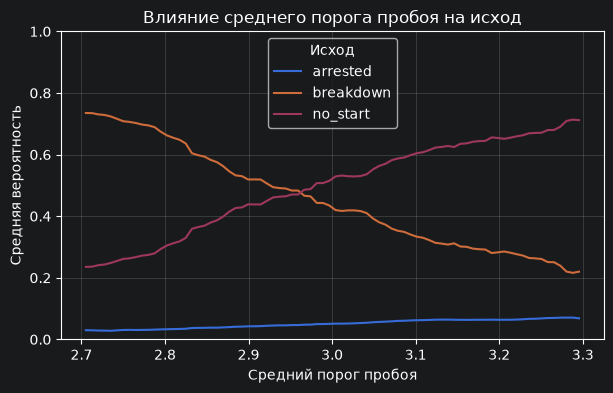

In [20]:
import numpy as np
background = X_cv.sample(n=min(3000, len(X_cv)), random_state=42)
field_min = X_cv["mean_breakdown_field"].quantile(0.01)
field_max = X_cv["mean_breakdown_field"].quantile(0.99)
field_grid = np.linspace(field_min, field_max, 80)
field_probabilities = []
for value in field_grid:
    changed = background.assign(mean_breakdown_field=value)
    field_probabilities.append(best_boost.predict_proba(changed).mean(axis=0))
field_probabilities = np.asarray(field_probabilities)
fig, ax = plt.subplots(figsize=(7, 4))
for index, label in enumerate(best_boost.classes_):
    ax.plot(field_grid, field_probabilities[:, index], label=label)
ax.set(xlabel="Средний порог пробоя", ylabel="Средняя вероятность", ylim=(0, 1))
ax.set_title("Влияние среднего порога пробоя на исход")
ax.legend(title="Исход")
ax.grid(alpha=0.3); plt.show()

### Влияние среднего порога пробоя

Увеличение среднего порога монотонно снижает вероятность полного пробоя и повышает вероятность отсутствия старта. Средняя граница между режимами расположена около 2.96, а остановка канала остаётся редким переходным исходом.

In [21]:
class_id = {name: i for i, name in enumerate(best_boost.classes_)}
difference = field_probabilities[:, class_id["breakdown"]] - field_probabilities[:, class_id["no_start"]]
transition_id = np.argmin(np.abs(difference))
transition_field = field_grid[transition_id]
transition_probs = field_probabilities[transition_id]
print(f"Средняя граница: {transition_field:.3f}")
print(f"P(breakdown): {transition_probs[class_id['breakdown']]:.3f}")
print(f"P(no_start): {transition_probs[class_id['no_start']]:.3f}")

Средняя граница: 2.959
P(breakdown): 0.483
P(no_start): 0.470


### Фазовая карта вероятности пробоя

Строим вероятность полного пробоя в зависимости от среднего порога и корреляционной длины. Влияние `eta` и формы распределения Вейбулла усредняется.

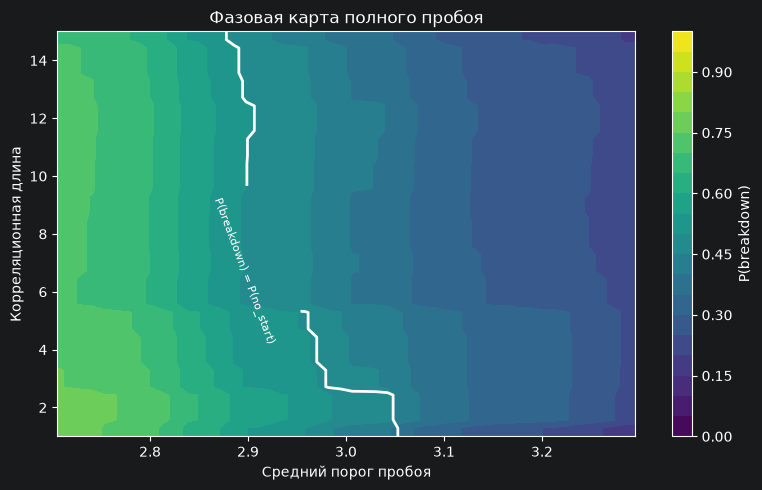

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_features = [
    "eta", "mean_breakdown_field",
    "correlation_length", "weibull_shape"
]
class_id = {name: i for i, name in enumerate(best_boost.classes_)}

field_limits = X_cv["mean_breakdown_field"].quantile([0.01, 0.99])
length_limits = X_cv["correlation_length"].quantile([0.01, 0.99])

field_values = np.linspace(
    field_limits.iloc[0], field_limits.iloc[1], 50
)
length_values = np.linspace(
    length_limits.iloc[0], length_limits.iloc[1], 50
)

field_mesh, length_mesh = np.meshgrid(
    field_values, length_values
)

phase_points = pd.DataFrame({
    "mean_breakdown_field": field_mesh.ravel(),
    "correlation_length": length_mesh.ravel(),
})

phase_background = X_cv[
    ["eta", "weibull_shape"]
].sample(n=min(200, len(X_cv)), random_state=42)

phase_data = phase_points.merge(
    phase_background, how="cross"
)
phase_data = phase_data[model_features]

phase_prediction = best_boost.predict_proba(
    phase_data
)
phase_prediction = phase_prediction.reshape(
    len(phase_points), len(phase_background), -1
)
mean_phase_probability = phase_prediction.mean(axis=1)

breakdown_map = mean_phase_probability[
    :, class_id["breakdown"]
].reshape(field_mesh.shape)

no_start_map = mean_phase_probability[
    :, class_id["no_start"]
].reshape(field_mesh.shape)

boundary = breakdown_map - no_start_map

fig, ax = plt.subplots(figsize=(8, 5))

heat = ax.contourf(
    field_mesh,
    length_mesh,
    breakdown_map,
    levels=np.linspace(0, 1, 21),
    cmap="viridis",
)
fig.colorbar(
    heat,
    ax=ax,
    label="P(breakdown)",
)

boundary_line = ax.contour(
    field_mesh,
    length_mesh,
    boundary,
    levels=[0],
    colors="white",
    linewidths=2,
)
ax.clabel(
    boundary_line,
    fmt={0: "P(breakdown) = P(no_start)"},
    fontsize=8,
)

ax.set_xlabel("Средний порог пробоя")
ax.set_ylabel("Корреляционная длина")
ax.set_title("Фазовая карта полного пробоя")

plt.tight_layout()
plt.show()

### Вывод по фазовой карте

Средний порог пробоя является главным фактором перехода между полным пробоем и отсутствием старта. Увеличение корреляционной длины сдвигает границу в сторону меньших порогов, поэтому крупные коррелированные области в среднем затрудняют прохождение канала.

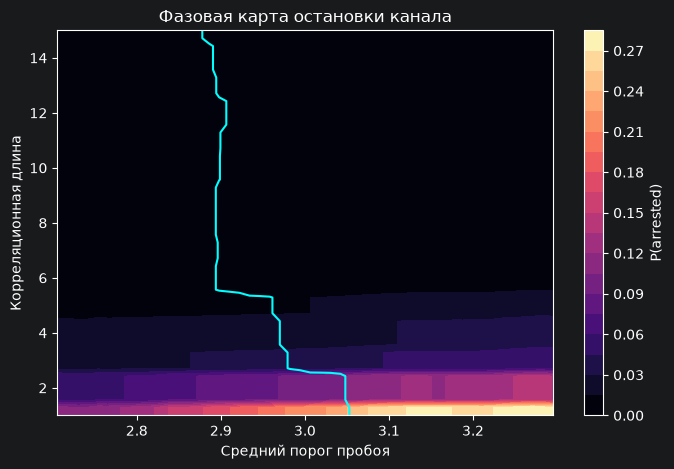

In [26]:
arrested_map = mean_phase_probability[
    :, class_id["arrested"]].reshape(field_mesh.shape)
fig, ax = plt.subplots(figsize=(8, 5))
heat = ax.contourf(field_mesh, length_mesh, arrested_map,
                   levels=20, cmap="magma")
fig.colorbar(heat, ax=ax, label="P(arrested)")
ax.contour(field_mesh, length_mesh, boundary,
           levels=[0], colors="cyan", linewidths=1.5)
ax.set(xlabel="Средний порог пробоя", ylabel="Корреляционная длина",
       title="Фазовая карта остановки канала")
plt.show()

### Область остановки канала

Остановка канала локализована преимущественно при малой корреляционной длине. В этой области слабые участки разрознены: канал может начать рост, но не находит непрерывного пути через образец.

In [27]:
maximum_index = np.unravel_index(
    np.argmax(arrested_map), arrested_map.shape)
maximum_probability = arrested_map[maximum_index]
maximum_field = field_mesh[maximum_index]
maximum_length = length_mesh[maximum_index]
print(f"Максимальная P(arrested): {maximum_probability:.3f}")
print(f"Средний порог: {maximum_field:.3f}")
print(f"Корреляционная длина: {maximum_length:.3f}")

Максимальная P(arrested): 0.283
Средний порог: 3.271
Корреляционная длина: 1.000


In [28]:
counts = pd.Series(y_cv).value_counts()

class_summary = pd.DataFrame({
    "Количество": counts,
    "Доля, %": (100 * counts / counts.sum()).round(2),
})

display(class_summary)

,Количество,"Доля, %"
status,,
no_start,8118,49.55
breakdown,7391,45.11
arrested,875,5.34


### Отдельная диагностика класса `arrested`

Проверяем, действительно ли модели не хватает примеров остановившихся каналов, или низкий recall связан с тем, что `arrested` является стохастическим переходным исходом.

Для каждого объекта получаем внефолдовое предсказание: его предсказывает модель, которая не обучалась на данной группе параметров.

In [31]:
from tqdm.auto import tqdm
oof_classes = np.asarray(best_boost.classes_)
oof_probability = np.full(
    shape=(len(X_cv), len(oof_classes)),
    fill_value=np.nan,
)
splits = cv.split(
    X_cv,
    y_cv,
    groups=groups_cv,
)
for fold, (train_idx, valid_idx) in enumerate(
    tqdm(splits, total=cv.get_n_splits(), desc="OOF CatBoost"),
    start=1,
):
    fold_model = clone(best_boost)
    fold_model.fit(
        X_cv.iloc[train_idx],
        y_cv.iloc[train_idx],
        verbose=False,
    )
    fold_probability = pd.DataFrame(
        fold_model.predict_proba(X_cv.iloc[valid_idx]),
        columns=fold_model.classes_,
    )

    fold_probability = fold_probability.reindex(
        columns=oof_classes,
        fill_value=0.0,
    )

    oof_probability[valid_idx] = fold_probability.to_numpy()
assert np.isfinite(oof_probability).all()

print("Форма массива вероятностей:", oof_probability.shape)
print("Классы:", oof_classes)

OOF CatBoost:   0%|          | 0/5 [00:00<?, ?it/s]

Форма массива вероятностей: (16384, 3)
Классы: ['arrested' 'breakdown' 'no_start']


In [32]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

is_arrested = (
    y_cv.to_numpy() == "arrested"
).astype(int)

arrested_column = np.flatnonzero(
    oof_classes == "arrested"
).item()

p_arrested_oof = oof_probability[:, arrested_column]
oof_prediction = oof_classes[
    np.argmax(oof_probability, axis=1)
]
predicted_arrested = (
    oof_prediction == "arrested"
).astype(int)
arrested_fraction = is_arrested.mean()
average_precision = average_precision_score(
    is_arrested,
    p_arrested_oof,
)
roc_auc = roc_auc_score(
    is_arrested,
    p_arrested_oof,
)
precision = precision_score(
    is_arrested,
    predicted_arrested,
    zero_division=0,
)
recall = recall_score(
    is_arrested,
    predicted_arrested,
    zero_division=0,
)
f1 = f1_score(
    is_arrested,
    predicted_arrested,
    zero_division=0,
)

print(f"Доля arrested: {arrested_fraction:.3f}")
print(f"Случайный уровень AP: {arrested_fraction:.3f}")
print(f"Average precision: {average_precision:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")
print()
print(f"Предсказано arrested: {predicted_arrested.sum()}")
print(f"Истинных arrested: {is_arrested.sum()}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

Доля arrested: 0.053
Случайный уровень AP: 0.053
Average precision: 0.435
ROC AUC: 0.939

Предсказано arrested: 639
Истинных arrested: 875
Precision: 0.463
Recall: 0.338
F1: 0.391


### Распознавание класса `arrested`

Несмотря на малую долю класса `arrested` — 5.3% выборки, CatBoost уверенно выделяет область его возникновения. `Average precision` составляет 0.435 при случайном уровне 0.053, а `ROC AUC` равен 0.939.

При стандартном выборе наиболее вероятного класса модель обнаруживает 33.8% остановившихся каналов, а precision составляет 46.3%. Следовательно, CatBoost извлекает устойчивый сигнал об остановке из физических параметров, поэтому дополнительная балансировка датасета на текущем этапе не требуется.

### Калибровка вероятности остановки

Проверяем, соответствует ли предсказанная вероятность `arrested` фактической доле остановившихся каналов. Это важно для физической интерпретации фазовой карты.

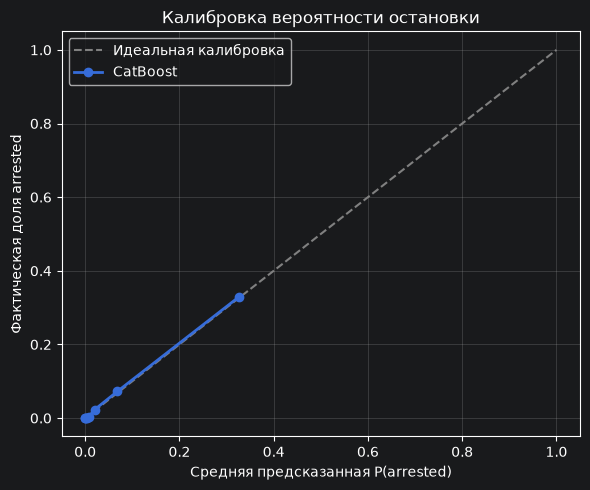

In [35]:
from sklearn.calibration import calibration_curve

arrested_true_fraction, arrested_mean_probability = calibration_curve(
    is_arrested,
    p_arrested_oof,
    n_bins=8,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Идеальная калибровка",
)

ax.plot(
    arrested_mean_probability,
    arrested_true_fraction,
    marker="o",
    linewidth=2,
    label="CatBoost",
)

ax.set_xlabel("Средняя предсказанная P(arrested)")
ax.set_ylabel("Фактическая доля arrested")
ax.set_title("Калибровка вероятности остановки")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Калибровка вероятности остановки

Калибровочная кривая CatBoost практически совпадает с идеальной диагональю. Предсказанная вероятность `arrested` соответствует фактической доле остановившихся каналов.

Следовательно, модель не только хорошо выделяет область возникновения остановки, но и корректно оценивает её вероятность. Редкость класса не приводит к заметному искажению вероятностного прогноза, поэтому дополнительная балансировка датасета и отдельная калибровка модели не требуются.

## Итоговые выводы

В ноутбуке исследована прямая задача:

$$
\left(\eta,\ E_{\mathrm{bd}}^{(0)},\ \ell_c,\ k\right)
\longrightarrow
P(\mathrm{no\_start},\ \mathrm{arrested},\ \mathrm{breakdown}).
$$

Здесь $\eta$ — параметр направленности роста, $E_{\mathrm{bd}}^{(0)}$ — средний порог пробоя, $\ell_c$ — корреляционная длина, а $k$ — параметр формы распределения Вейбулла.

Для предотвращения утечки одинаковые комбинации физических параметров целиком относились только к одной части групповой кросс-валидации.

Сравнение логистической регрессии, случайного леса и CatBoost показало, что CatBoost лучше всего оценивает вероятности исходов. После настройки его средний `log loss` на групповой кросс-валидации составил 0.7205. На независимом тесте из 4096 симуляций модель получила:

- accuracy — 0.646;
- balanced accuracy — 0.513;
- log loss — 0.671.

Главным параметром, определяющим исход симуляции, оказался средний порог пробоя $E_{\mathrm{bd}}^{(0)}$. При его увеличении вероятность полного пробоя уменьшается, а вероятность отсутствия старта растёт. Усреднённая граница между этими режимами расположена около

$$
E_{\mathrm{bd}}^{(0)} \approx 2.96.
$$

Корреляционная длина $\ell_c$ изменяет положение границы режимов. При её увеличении граница сдвигается в сторону меньшего среднего порога. Следовательно, крупные коррелированные области в среднем затрудняют прохождение канала через образец.

Режим `arrested` возникает преимущественно при малой корреляционной длине. Максимальная предсказанная вероятность остановки составила 0.283 при

$$
E_{\mathrm{bd}}^{(0)} = 3.271,
\qquad
\ell_c = 1.0.
$$

Несмотря на то что класс `arrested` составляет только 5.3% обучающей выборки, CatBoost хорошо выделяет область его возникновения:

- average precision — 0.435 при случайном уровне 0.053;
- ROC AUC — 0.939;
- precision — 0.463;
- recall — 0.338;
- F1 — 0.391.

Калибровочная кривая вероятности `arrested` практически совпадает с идеальной диагональю. Следовательно, предсказанные вероятности согласуются с фактическими частотами остановки и подходят для физической интерпретации фазовых карт.

Таким образом, существующего датасета достаточно для прямой вероятностной классификации исходов. Искусственное выравнивание классов и дополнительная генерация `arrested` сейчас не требуются.

Следующий этап проекта — решение обратной задачи:

$$
\text{морфологические характеристики дерева}
\longrightarrow
\left(\eta,\ E_{\mathrm{bd}}^{(0)},\ \ell_c,\ k\right).
$$